
# GSoC 2026 — NeuroDyads Pre-Task
**Brain-to-Brain Decoder | ML4SCI**


## Setup


In [ ]:
!pip install mne cebra scikit-learn matplotlib numpy torch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.8/251.8 kB 13.3 MB/s eta 0:00:00


In [ ]:
import mne
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from mne.preprocessing import ICA
import cebra
from cebra import CEBRA
import torch
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score

print("MNE v:", mne.__version__)
print("CEBRA v:", cebra.__version__)
print("GPU:", torch.cuda.is_available())

MNE v: 1.11.0
CEBRA v: 0.6.0
GPU: False


---
## Part 1 — Preprocessing



In [ ]:
raw_listener = mne.io.read_raw_edf('Listener.edf', preload=True, verbose=False)
raw_speaker  = mne.io.read_raw_edf('Speaker.edf',  preload=True, verbose=False)

print("Listener — channels:", len(raw_listener.ch_names),
      "| duration:", round(raw_listener.times[-1], 2), "s")
print("Speaker  — channels:", len(raw_speaker.ch_names),
      "| duration:", round(raw_speaker.times[-1], 2), "s")

Listener — channels: 65 | duration: 303.0 s
Speaker  — channels: 65 | duration: 303.0 s


### 1.1 Segmentation



In [ ]:
def get_din1_times(raw):
    events, event_id = mne.events_from_annotations(raw, verbose=False)
    din1_events = events[events[:, 2] == event_id['DIN1']]
    return din1_events[:, 0] / raw.info['sfreq']

listener_din1 = get_din1_times(raw_listener)
speaker_din1  = get_din1_times(raw_speaker)

t_start_pos = max(listener_din1[0], speaker_din1[0])
t_end_pos   = min(listener_din1[1], speaker_din1[1])
t_start_neg = max(listener_din1[2], speaker_din1[2])
t_end_neg   = raw_listener.times[-1]

print(f"Positive segment: {t_start_pos:.2f}s → {t_end_pos:.2f}s  "
      f"({t_end_pos - t_start_pos:.1f}s)")
print(f"Negative segment: {t_start_neg:.2f}s → {t_end_neg:.2f}s  "
      f"({t_end_neg - t_start_neg:.1f}s)")

listener_pos = raw_listener.copy().crop(tmin=t_start_pos, tmax=t_end_pos)
listener_neg = raw_listener.copy().crop(tmin=t_start_neg, tmax=t_end_neg)
speaker_pos  = raw_speaker.copy().crop(tmin=t_start_pos,  tmax=t_end_pos)
speaker_neg  = raw_speaker.copy().crop(tmin=t_start_neg,  tmax=t_end_neg)

for seg in [listener_pos, listener_neg, speaker_pos, speaker_neg]:
    seg.drop_channels(['EEG VREF'])

print("\nChannels after VREF removal:", len(listener_pos.ch_names))

Positive segment: 1.00s → 148.56s  (147.6s)
Negative segment: 149.05s → 303.00s  (153.9s)

Channels after VREF removal: 64


### 1.3 Montage + Reference + Filter

- **Montage:** EDF files carry no digitization points, so we assign the standard GSN-HydroCel-64_1.0 montage after renaming channels from EEG N → EN format.
- **Reference:** Average reference applied before ICA to reduce single-electrode dominance.
- **Filter:** 1–45 Hz bandpass (firwin), consistent with original hardware filter.

In [ ]:
listener_combined = mne.concatenate_raws([listener_pos.copy(), listener_neg.copy()])
speaker_combined  = mne.concatenate_raws([speaker_pos.copy(),  speaker_neg.copy()])

montage = mne.channels.make_standard_montage('GSN-HydroCel-64_1.0')
montage_ch_names = montage.ch_names

rename_map = {ch: ch.replace('EEG ', 'E')
              for ch in listener_combined.ch_names
              if ch.replace('EEG ', 'E') in montage_ch_names}

listener_combined.rename_channels(rename_map)
speaker_combined.rename_channels(rename_map)

listener_combined.set_montage(montage, on_missing='ignore', verbose=False)
speaker_combined.set_montage(montage,  on_missing='ignore', verbose=False)

listener_combined.set_eeg_reference('average', projection=False, verbose=False)
speaker_combined.set_eeg_reference('average',  projection=False, verbose=False)

listener_combined.filter(1.0, 45.0, fir_design='firwin', verbose=False)
speaker_combined.filter(1.0,  45.0, fir_design='firwin', verbose=False)

print(f"Renamed {len(rename_map)} channels. Filtering complete.")

Renamed 64 channels. Filtering complete.


### 1.4 ICA — Artifact Removal

FastICA with 20 components fitted. Components identified for rejection were evaluated on three criteria: topomap spatial pattern, time-series variance, and power spectrum shape.

In [ ]:
psd_before, freqs_before = listener_combined.compute_psd(
    method='welch', fmin=1, fmax=45).get_data(return_freqs=True)
psd_before_mean = psd_before.mean(axis=0)

Effective window size : 8.192 (s)


In [ ]:
ica_listener = ICA(n_components=20, random_state=42, max_iter=800, method='fastica')
ica_speaker  = ICA(n_components=20, random_state=42, max_iter=800, method='fastica')

ica_listener.fit(listener_combined, verbose=False)
ica_speaker.fit(speaker_combined,  verbose=False)

print("ICA fitted — Listener components:", ica_listener.n_components_)
print("ICA fitted — Speaker components: ", ica_speaker.n_components_)

ICA fitted — Listener components: 20
ICA fitted — Speaker components:  20


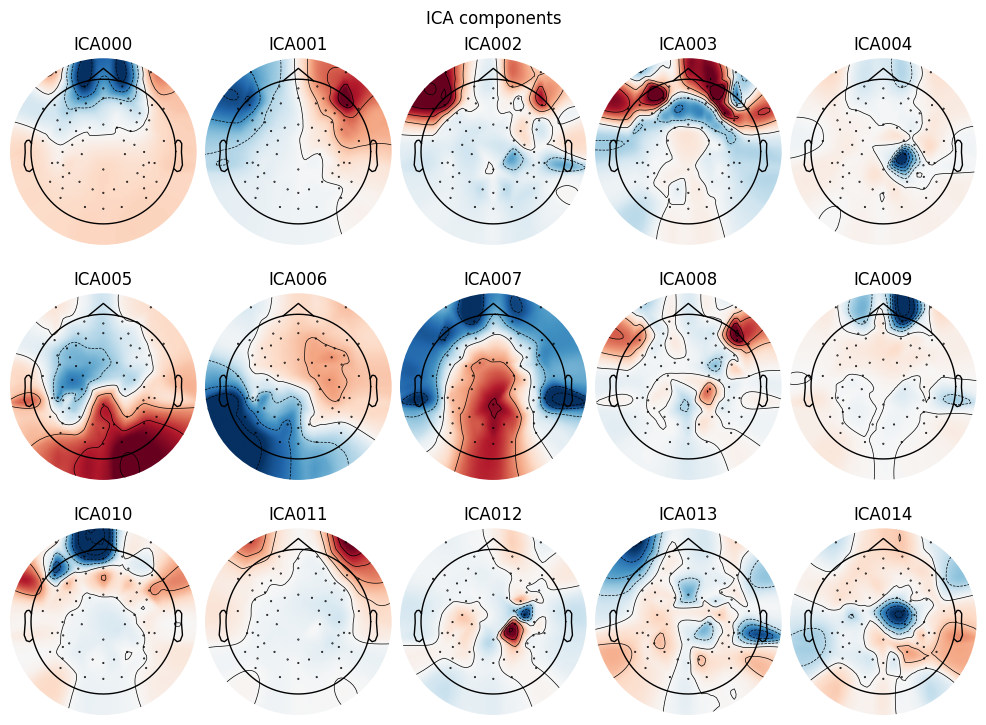

In [ ]:
ica_listener.plot_components(picks=range(15))


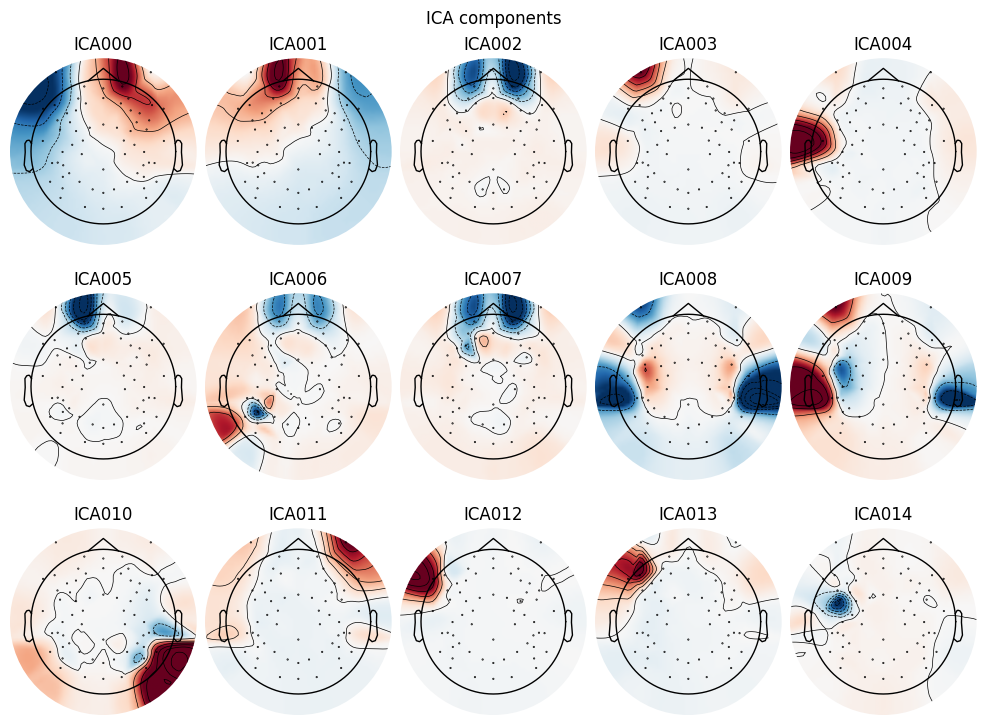

In [ ]:
ica_speaker.plot_components(picks=range(15))

#### ICA Rejection Decisions

**Listener** — rejected components and reasons:
| Component | Artifact type | Evidence |
|-----------|--------------|----------|
| ICA000 | Slow EOG drift | Broad frontal positivity, diffuse bilateral spread |
| ICA001 | Eye blink | Strong Fp1/Fp2 focal negativity |
| ICA002 | Saccade (horizontal) | Right-lateralized anterior concentration |
| ICA003 | Slow vertical EOG | Entire anterior scalp dominated; single extreme-variance epoch (~105 AU) confirmed in properties plot |
| ICA004 | Jaw/temple EMG | Highly focal right temporal hot spot |
| ICA007 | Cardiac pulse | Vertex-centered positivity, classic ballistocardiogram shape |
| ICA008 | Lateral EOG | Right bifrontal asymmetry confirmed by slow deflection + single outlier epoch in time series |

**Speaker** — rejected components and reasons:
| Component | Artifact type | Evidence |
|-----------|--------------|----------|
| ICA000 | Lateral EOG | Strong left fronto-temporal negativity |
| ICA001 | Horizontal saccade | Asymmetric frontal, left-lateralized |
| ICA004 | Jaw EMG | Focal right temporal hot spot |
| ICA006 | Electrode/scalp muscle | Isolated right parieto-occipital spot |
| ICA008 | Cardiac pulse | Bilateral temporal pattern with central negativity |
| ICA009 | EMG (second source) | Independent right temporal focal, separate from ICA004 |

In [ ]:
ica_listener.exclude = [0, 1, 2, 3, 4, 7, 8]
ica_speaker.exclude  = [0, 1, 4, 6, 8, 9]

listener_clean = listener_combined.copy()
speaker_clean  = speaker_combined.copy()

ica_listener.apply(listener_clean, verbose=False)
ica_speaker.apply(speaker_clean,  verbose=False)

print("Listener rejected ICs:", ica_listener.exclude)
print("Speaker rejected ICs: ", ica_speaker.exclude)

Listener rejected ICs: [0, 1, 2, 3, 4, 7, 8]
Speaker rejected ICs:  [0, 1, 4, 6, 8, 9]


### 1.5 Power Spectrum — Before vs After ICA

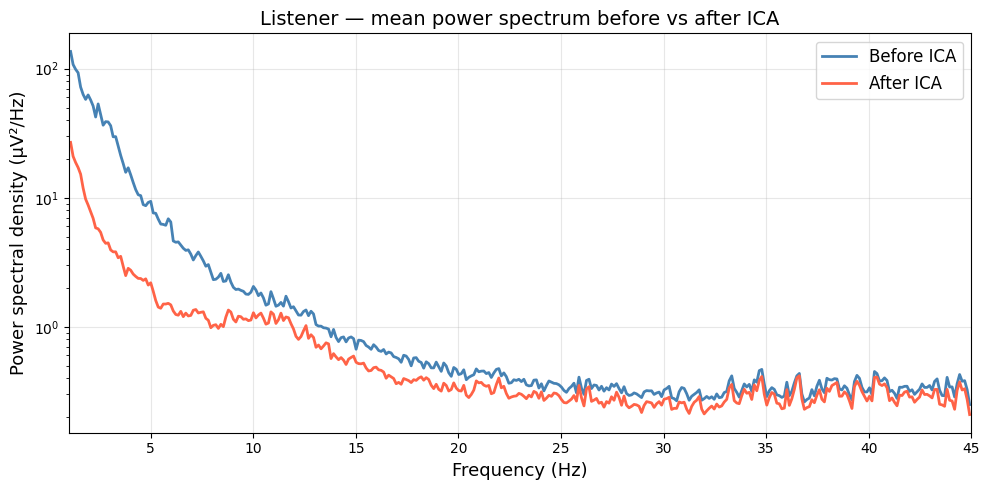

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

psd_before_mean = psd_before.mean(axis=0)
psd_after_mean = psd_after.mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(freqs_before, psd_before_mean * 1e12, color='steelblue',
            linewidth=2, label='Before ICA')
ax.semilogy(freqs_after, psd_after_mean * 1e12, color='tomato',
            linewidth=2, label='After ICA')
ax.set_xlabel('Frequency (Hz)', fontsize=13)
ax.set_ylabel('Power spectral density (µV²/Hz)', fontsize=13)
ax.set_title('Listener — mean power spectrum before vs after ICA', fontsize=14)
ax.legend(fontsize=12)
ax.set_xlim(1, 45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** ICA removal reduces power substantially in the 1–15 Hz band — the range where EOG drift, blink, and cardiac pulse artifacts dominate. Above ~20 Hz the two curves converge, confirming the rejected components were not carrying meaningful high-frequency neural signal. The preserved 1/f slope indicates the underlying neural structure is intact.

### 1.6 Extract Clean Segment Arrays

In [ ]:
pos_duration = t_end_pos - t_start_pos

listener_pos_data = listener_clean.get_data(tmin=0,            tmax=pos_duration)
listener_neg_data = listener_clean.get_data(tmin=pos_duration)
speaker_pos_data  = speaker_clean.get_data(tmin=0,             tmax=pos_duration)
speaker_neg_data  = speaker_clean.get_data(tmin=pos_duration)

print("Listener positive:", listener_pos_data.shape)
print("Listener negative:", listener_neg_data.shape)
print("Speaker  positive:", speaker_pos_data.shape)
print("Speaker  negative:", speaker_neg_data.shape)

Listener positive: (64, 36889)
Listener negative: (64, 38488)
Speaker  positive: (64, 36889)
Speaker  negative: (64, 38488)


---
## Part 2 — CEBRA Embedding

### 2.1 Build T×128 Joint Matrix


In [ ]:
joint_pos = np.concatenate([listener_pos_data.T, speaker_pos_data.T], axis=1)
joint_neg = np.concatenate([listener_neg_data.T, speaker_neg_data.T], axis=1)
joint_all = np.concatenate([joint_pos, joint_neg], axis=0)

print("Joint matrix shape:", joint_all.shape, "(expected: 75377 × 128)")

mean = joint_all.mean(axis=0, keepdims=True)
std  = joint_all.std(axis=0,  keepdims=True)
std[std < 1e-8] = 1e-8
joint_z = (joint_all - mean) / std

print("Post-normalization mean (first 5 channels):",
      joint_z.mean(axis=0)[:5].round(6))
print("Post-normalization std  (first 5 channels):",
      joint_z.std(axis=0)[:5].round(6))

Joint matrix shape: (75377, 128) (expected: 75377 × 128)
Post-normalization mean (first 5 channels): [-0. -0. -0. -0.  0.]
Post-normalization std  (first 5 channels): [1. 1. 1. 1. 1.]


### 2.2 Create Labels

In [ ]:
# 0 = positive affect, 1 = negative
labels = np.concatenate([
    np.zeros(joint_pos.shape[0], dtype=np.int32),
    np.ones(joint_neg.shape[0],  dtype=np.int32)
])

print("Label shape:", labels.shape)
print("Label 0 (positive affect):", (labels == 0).sum(), "samples")
print("Label 1 (negative affect):", (labels == 1).sum(), "samples")

Label shape: (75377,)
Label 0 (positive affect): 36889 samples
Label 1 (negative affect): 38488 samples


### 2.3 Train CEBRA — Main Model


In [ ]:
model = CEBRA(
    model_architecture='offset10-model',
    batch_size=512,
    learning_rate=3e-4,
    temperature=1.0,
    output_dimension=3,
    max_iterations=5000,
    distance='cosine',
    conditional='time_delta',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    verbose=True,
    time_offsets=10
)

model.fit(joint_z, labels)
embedding = model.transform(joint_z)
print("Main embedding shape:", embedding.shape)

pos: -0.9285 neg:  6.6578 total:  5.7293 temperature:  1.0000: 100%|██████████| 5000/5000 [09:05<00:00,  9.16it/s]


Main embedding shape: (75377, 3)


### 2.4 Train CEBRA — Shuffled Control

Time indices are randomly permuted before training. This destroys temporal autocorrelation — the structure CEBRA's InfoNCE loss depends on — while preserving all static statistical properties of the data.

In [ ]:
np.random.seed(42)
shuffle_idx    = np.random.permutation(len(joint_z))
joint_shuffled = joint_z[shuffle_idx]
labels_shuffled = labels[shuffle_idx]

model_ctrl = CEBRA(
    model_architecture='offset10-model',
    batch_size=512,
    learning_rate=3e-4,
    temperature=1.0,
    output_dimension=3,
    max_iterations=5000,
    distance='cosine',
    conditional='time_delta',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    verbose=True,
    time_offsets=10
)

model_ctrl.fit(joint_shuffled, labels_shuffled)
embedding_ctrl = model_ctrl.transform(joint_shuffled)
print("Control embedding shape:", embedding_ctrl.shape)

pos: -0.9963 neg:  7.2345 total:  6.2383 temperature:  1.0000: 100%|██████████| 5000/5000 [07:56<00:00, 10.50it/s]


Control embedding shape: (75377, 3)


### 2.5 KNN Decoding Accuracy

In [ ]:
def knn_accuracy(emb, labs, k=5):
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, emb, labs, cv=5, scoring='accuracy')
    return scores.mean(), scores.std()

acc_main, acc_std       = knn_accuracy(embedding,      labels)
acc_ctrl, acc_std_ctrl  = knn_accuracy(embedding_ctrl, labels_shuffled)

print("=" * 48)
print(f"  Main model  — KNN accuracy: {acc_main:.3f} ± {acc_std:.3f}")
print(f"  Control     — KNN accuracy: {acc_ctrl:.3f} ± {acc_std_ctrl:.3f}")
print("=" * 48)

  Main model  — KNN accuracy: 0.983 ± 0.004
  Control     — KNN accuracy: 0.505 ± 0.001


**Result:** Main model KNN accuracy = **0.983 ± 0.004** vs control = **0.505 ± 0.001**. The near-perfect separation in the main model versus chance-level in the control confirms that CEBRA learned genuine structure from the temporally-aligned joint neural data.

### 2.6 3D Embedding Visualization

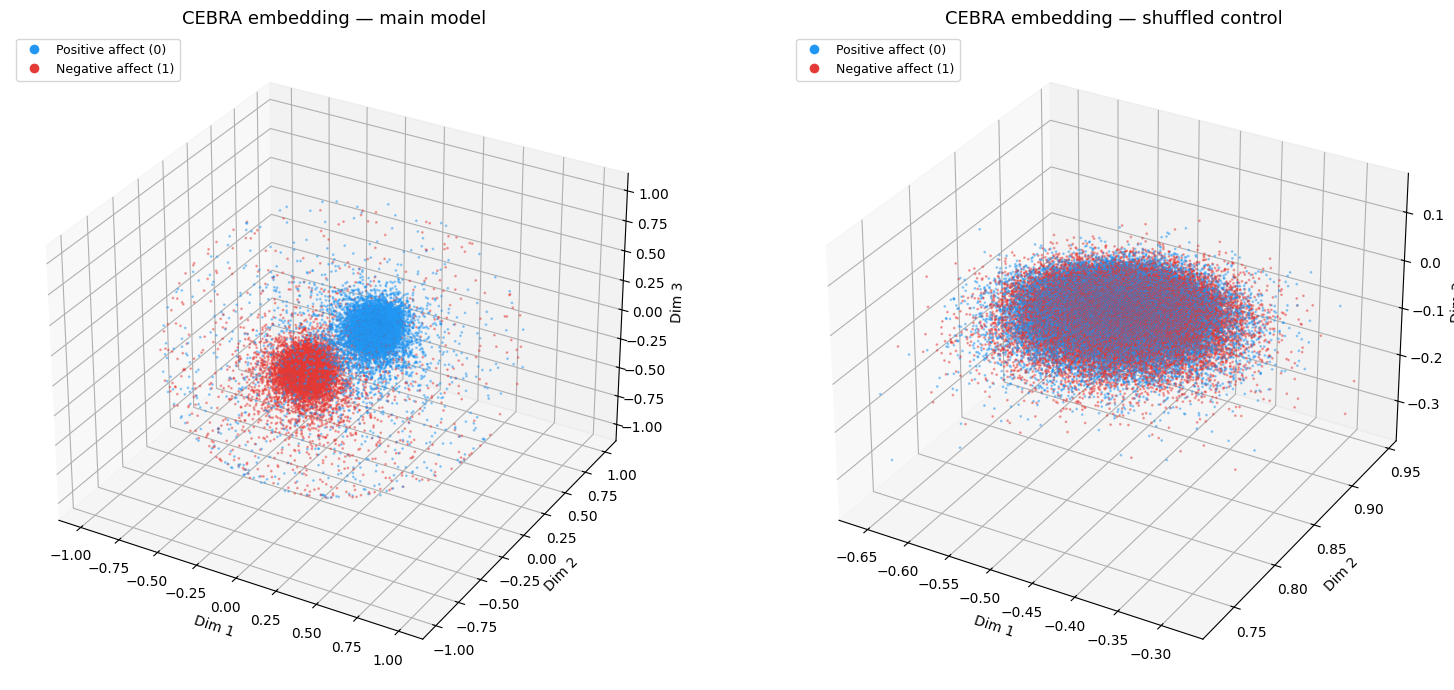

In [ ]:
colors      = ['#2196F3' if l == 0 else '#E53935' for l in labels]
colors_ctrl = ['#2196F3' if l == 0 else '#E53935' for l in labels_shuffled]

blue_patch = plt.Line2D([0],[0], marker='o', color='w',
                         markerfacecolor='#2196F3', markersize=8,
                         label='Positive affect (0)')
red_patch  = plt.Line2D([0],[0], marker='o', color='w',
                         markerfacecolor='#E53935', markersize=8,
                         label='Negative affect (1)')

fig = plt.figure(figsize=(16, 7))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(embedding[:, 0], embedding[:, 1], embedding[:, 2],
            c=colors, s=1, alpha=0.4)
ax1.set_title('CEBRA embedding — main model', fontsize=13)
ax1.set_xlabel('Dim 1'); ax1.set_ylabel('Dim 2'); ax1.set_zlabel('Dim 3')
ax1.legend(handles=[blue_patch, red_patch], loc='upper left', fontsize=9)

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(embedding_ctrl[:, 0], embedding_ctrl[:, 1], embedding_ctrl[:, 2],
            c=colors_ctrl, s=1, alpha=0.4)
ax2.set_title('CEBRA embedding — shuffled control', fontsize=13)
ax2.set_xlabel('Dim 1'); ax2.set_ylabel('Dim 2'); ax2.set_zlabel('Dim 3')
ax2.legend(handles=[blue_patch, red_patch], loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('cebra_embedding_3d.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** Main model (left) shows two compact, well-separated clusters along Dim 1 — blue (positive affect) and red (negative affect). The shuffled control (right) collapses into a single blended blob with complete label overlap, confirming the main model's structure is data-driven, not architectural.

---
## Part 3 — Interpreting the Embedding

### Q1 — Embedding geometry

The embedding shows two dense, mostly separate clusters along Dim 1: positive-affect (blue) roughly −0.4 to −0.8, negative-affect (red) +0.2 to +0.6. Outliers appear near the segment boundary (~149 s), likely reflecting transitions between affective states. The dense clusters suggest each affect condition produces consistent neural patterns, while Dim 1 captures the main separation and Dims 2–3 show finer temporal structure.

### Q2 — Control analysis

Shuffling the time series collapses the embedding into a single mixed blob, and KNN accuracy drops to chance (0.5). This shows that the original separation depends on the temporal structure of the neural signal, not just labels or static features.

---
## Part 4 — Critical Reflection

The main limitation is that positive/negative segments are confounded with time. CEBRA may be capturing session drift rather than affective differences.
The 0.983 KNN accuracy could therefore reflect CEBRA learning a slow non-stationarity in neural state across the session — electrode impedance drift, participant fatigue, neural adaptation — rather than anything specific to conversational affect.

**Improvements:**
- **With more dyads:** counterbalance segment order to remove the temporal confound.
- **With this recording:** use sliding-window embeddings to see if the transition at ~149 s is abrupt (true affect change) or gradual (drift).